In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

from bio_network.engine.neurons import IzhikevichPopulation
from bio_network.engine.scheduler import simulate
from bio_network.engine.synapses import RandomSynapses
from bio_network.viz.raster import (
    plot_population_rate,
    plot_raster,
    plot_voltage_trace,
)

T_MS = 1000
N_EXC = 800
N_INH = 200
SEED = 42

OUTPUT_DIR = os.path.join(os.getcwd(), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


Output directory: A:\Bio Network\notebooks\output


In [2]:
population = IzhikevichPopulation(n_excitatory=N_EXC, n_inhibitory=N_INH, seed=SEED)
synapses = RandomSynapses(n_pre_excit=N_EXC, n_pre_inhib=N_INH, seed=SEED)
recording = simulate(population, synapses, T_ms=T_MS, seed=SEED)
print(f"Simulated {T_MS} ms of {recording.n_neurons} neurons with {recording.times_ms.size} spikes.")


Simulated 1000 ms of 1000 neurons with 9737 spikes.


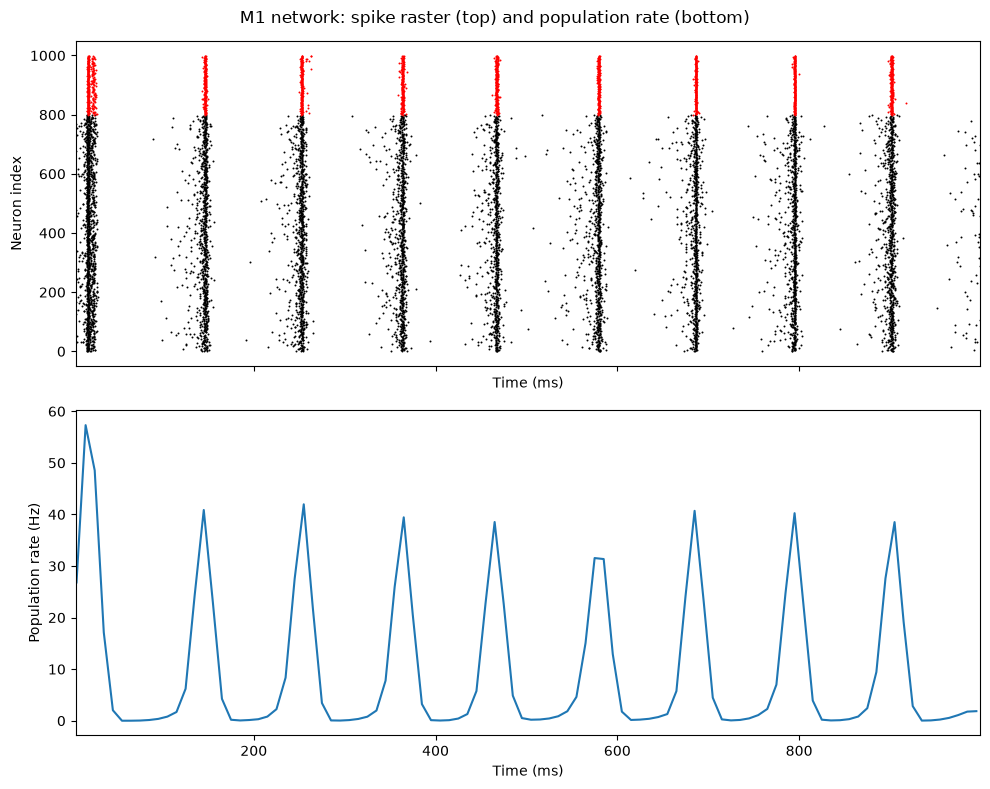

In [3]:
fig, (ax_raster, ax_rate) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
plot_raster(recording, ax=ax_raster)
plot_population_rate(recording, bin_ms=10, ax=ax_rate)
ax_rate.set_xlabel("Time (ms)")
fig.suptitle("M1 network: spike raster (top) and population rate (bottom)")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m1_raster_and_population_rate.png"), dpi=150)
plt.show()


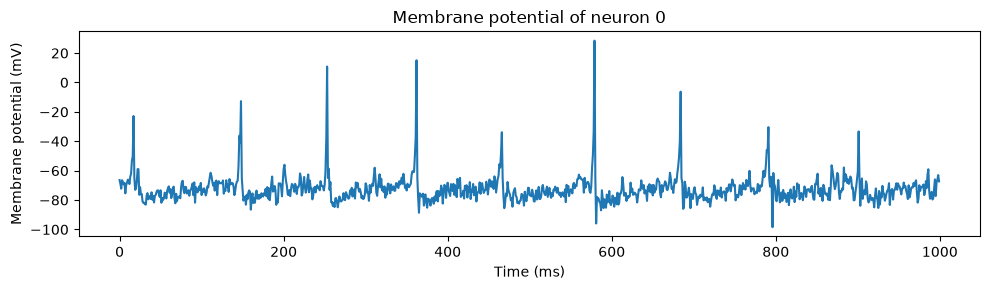

In [4]:
trace_population = IzhikevichPopulation(n_excitatory=N_EXC, n_inhibitory=N_INH, seed=SEED)
trace_synapses = RandomSynapses(n_pre_excit=N_EXC, n_pre_inhib=N_INH, seed=SEED)
rng = np.random.default_rng(SEED)
v_history = np.zeros((trace_population.v.size, T_MS), dtype=float)
synaptic = np.zeros(trace_population.v.size)
for t in range(T_MS):
    current = np.zeros(trace_population.v.size)
    current[:N_EXC] = 5.0 * rng.standard_normal(N_EXC)
    current[N_EXC:] = 2.0 * rng.standard_normal(N_INH)
    fired = trace_population.step(current + synaptic)
    v_history[:, t] = trace_population.v
    synaptic = trace_synapses.deliver(fired) if fired.size else np.zeros(trace_population.v.size)

fig, ax = plt.subplots(figsize=(10, 3))
plot_voltage_trace(v_history, neuron_index=0, ax=ax)
ax.set_title("Membrane potential of neuron 0")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m1_voltage_trace_neuron0.png"), dpi=150)
plt.show()


In [5]:
rates = recording.mean_rates_hz()
exc_rates = rates[:N_EXC]
inh_rates = rates[N_EXC:]
print(f"Total spikes: {recording.times_ms.size}")
print(f"Mean excitatory rate: {exc_rates.mean():.2f} Hz")
print(f"Mean inhibitory rate: {inh_rates.mean():.2f} Hz")
print(f"Max rate: {rates.max():.2f} Hz")


Total spikes: 9737
Mean excitatory rate: 9.76 Hz
Mean inhibitory rate: 9.64 Hz
Max rate: 14.00 Hz
